<a href="https://colab.research.google.com/github/Luke-Dev-Tech/Business_intelligence_and_data-mining/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

# **[1] Introduction**

The purpose of this project was to investigate how customers behave and forecast the reaction to a marketing campaign for a retail client who has a limited contact budget. The business issue here is that the target is inefficient.

The marketing team need an effective method to prioritize customers for the next campaign as well as customize messages and offers to each type of customer.

We used the "Customer Personality Analysis" dataset from kaggle.com. This dataset had 2,240 customer records and 29 variables. Each row in the data represented one customer. The columns contained demographic information and income, household composition, customer enrollment date, recency (the time since last interaction), spending across product categories, number of purchases made by channel, whether or not they accepted the previous campaign, if they filed complaints and a binary response variable for the most recent campaign.

This project answered three questions:

1. What customer segments exist based on their value, recency, purchase frequency and behavior by channel.

2. What were the strongest correlations to campaign response.

3. Who are the best customers to pursue with a ranked list based on the predicted likelihood of responding.

# **[2] Import Libraries**

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# **[3] Load Dataset**

In [317]:
url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"

In [318]:
df = pd.read_csv(url, sep='\t')
df.head()
df.tail()
display(df.info())
display(df.describe())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# **[4] Data Cleaning & Feature Engineering**

# [4.1] Viewing the missing data


In [319]:
print("Start of Part 4 shape:", df.shape)
print("Top missing columns before:\n", df.isna().sum().sort_values(ascending=False).head(15))

Start of Part 4 shape: (2240, 29)
Top missing columns before:
 Income              24
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64


The start records the dataset size and missing values before cleaning for a comparison after

# [4.2] Create Age Feature

This section creates a reproducible age feature using the dataset timeline, then caps unrealistic ages.

In [320]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Year_Birth"] = pd.to_numeric(df["Year_Birth"], errors="coerce")

as_of = df["Dt_Customer"].max()
df["Age"] = as_of.year - df["Year_Birth"]
df["Age"] = df["Age"].clip(lower=18, upper=100)

print("Age reference date:", as_of.date())
print("Age min/max:", df["Age"].min(), df["Age"].max())

Age reference date: 2014-06-29
Age min/max: 18 100


# [4.3] Convert Date Column

This Converts Dt_Customer to datetime and shows how many rows ended up failing parsing.

In [321]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
print("Null Dt_Customer:", int(df["Dt_Customer"].isna().sum()))

Null Dt_Customer: 0


# [4.4] Drop Unnecessary Columns

This sections removes identifier and constant columns and checks duplicate customers, then prints how many columns remain.

**Handle Missing Values Part A**

In [322]:
before_cols = df.shape[1]

df = df.drop(columns=["ID"], errors="ignore")

for c in ["Z_CostContact", "Z_Revenue"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

print("Columns before:", before_cols, "after:", df.shape[1])

Columns before: 30 after: 27


In [323]:
print("Columns after:", df.shape[1])

Columns after: 27


Here we fill the missing values using mean for numeric, mode for categorical, and keeps binary flags as 0 or 1. We use mean on the numeric columns to ensure that all customers are included in the analysis and to avoid bias in the results due to the removal of rows.

In [324]:
print(df.isna().sum().sort_values(ascending=False).head(15))

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
binary_cols = [c for c in binary_cols if c in df.columns]
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].mode()[0]).astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in binary_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Total nulls after:", int(df.isna().sum().sum()))

Income               24
Education             0
Year_Birth            0
Marital_Status        0
Kidhome               0
Teenhome              0
Dt_Customer           0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumDealsPurchases     0
dtype: int64
Total nulls after: 0


**Handle Missing Values Part B**

Then part B Fixes invalid negative values for fields that should never be negative.

In [325]:
nonneg_cols = [
    "Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]
for c in nonneg_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = 0

**Handle Missing Values Part C**

Finally, this part clips any extreme income and spend outliers to reduce their impact on clustering and models.

In [326]:
def clip_percentiles(s, low=0.01, high=0.99):
    return s.clip(s.quantile(low), s.quantile(high))

for c in ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]:
    if c in df.columns:
        df[c] = clip_percentiles(df[c], 0.01, 0.99)

# [4.5] Final check after cleaning

In [327]:
print("Final shape:", df.shape)
print("Top missing columns after:\n", df.isna().sum().sort_values(ascending=False).head(15))

Final shape: (2240, 27)
Top missing columns after:
 Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumDealsPurchases    0
dtype: int64


# **[5] Exploratory Data Analysis (EDA)**

## [5.1] Boxplot Analysis (visualization)

In [328]:
import seaborn as sns

features = [
    "Income",
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency",
    "Age"
]


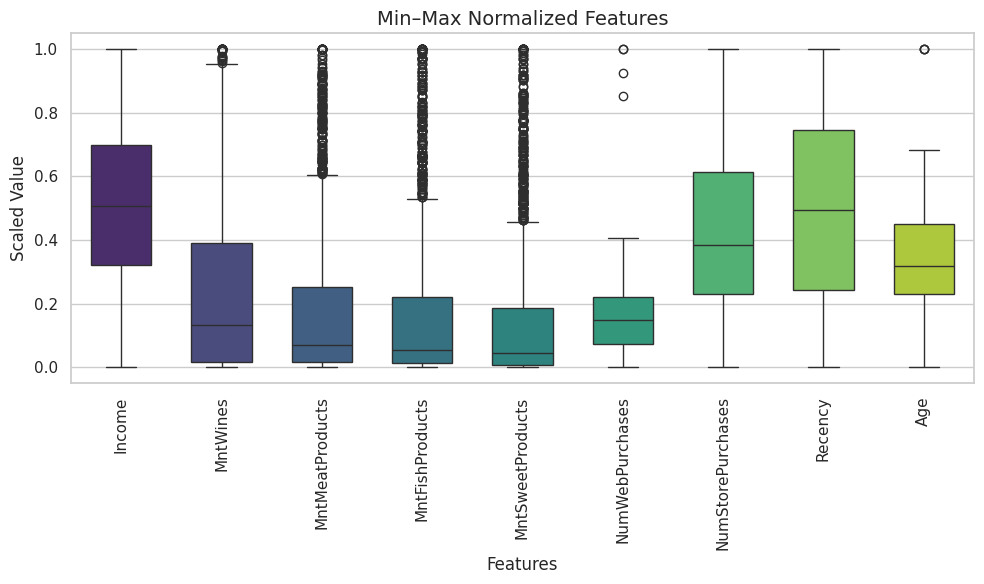

In [329]:
# Min–Max
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_mm,
    palette="viridis",
    width=0.6
)

plt.title("Min–Max Normalized Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

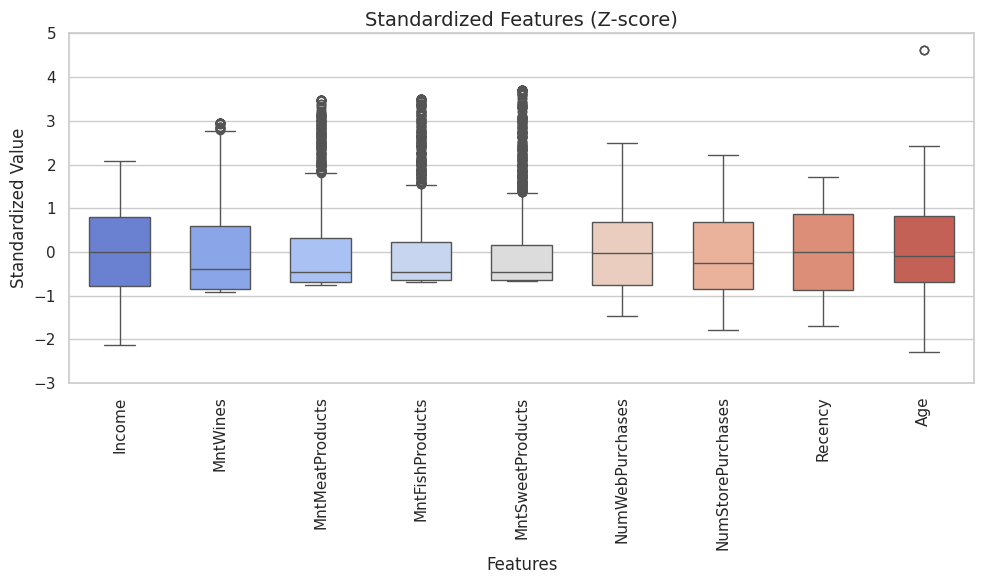

In [330]:
# Standardized
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = pd.DataFrame(sc.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_sc,
    palette="coolwarm",
    width=0.6
)

plt.ylim([-3,5])
plt.title("Standardized Features (Z-score)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Standardized Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**Business Insights**

**Wine**: Wine is the most reliable product because almost all customers buy it consistently.

**High Spenders**: Revenue in meat, fish, and sweets relies heavily on a very small group of high-spending VIP customers.

**Sales Channels**: Most customers shop predictably in physical stores, while online sales depend entirely on a few highly active users.

**Customer Habits**: Customers have steady incomes and predictable return visits, making them perfect targets for automated subscription services.


## [5.2] Income Distribution

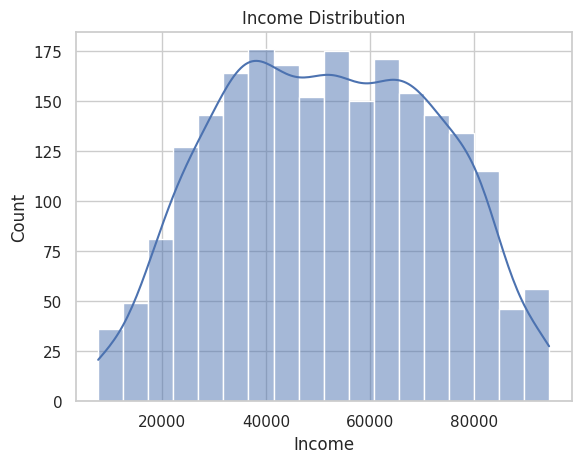

In [331]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()


The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

## [5.3] Spending Correlation Heatmap

In [332]:
import pandas as pd

# Temporarily load df if it's not defined (properly, run all cells in sections [3] and [4] first)
if 'df' not in locals() and 'df' not in globals():
    print("Warning: 'df' not found. Loading raw data. Please ensure all upstream cells are run for proper data cleaning.")
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')

spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_df = df[spending_cols]

corr_matrix = spending_df.corr()

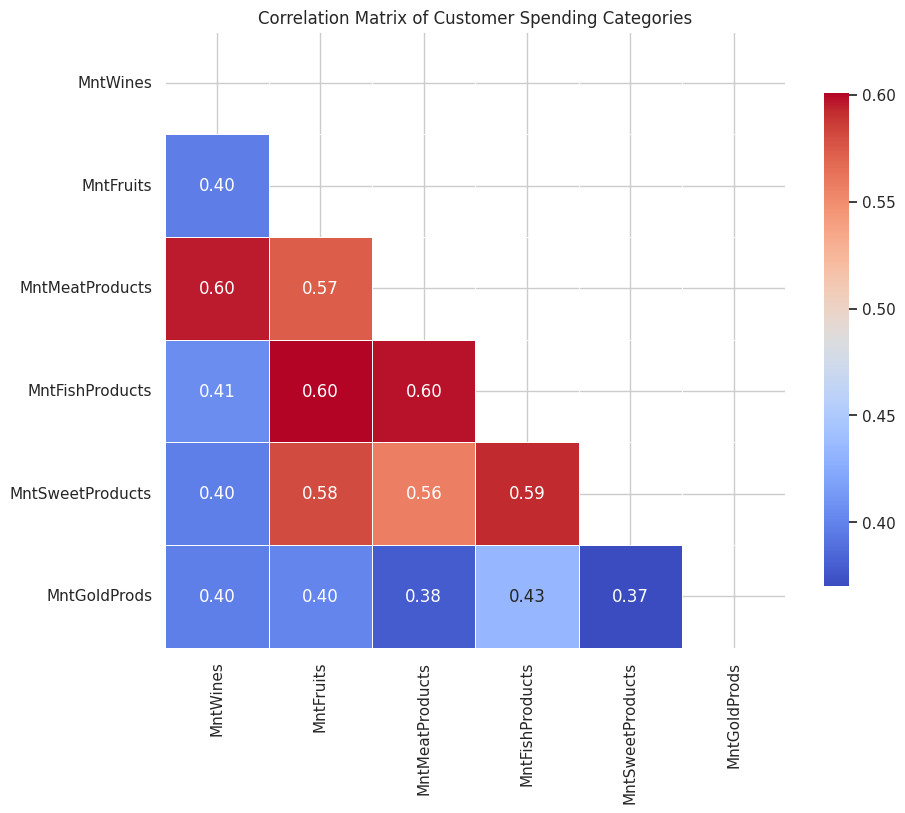

In [333]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Customer Spending Categories")
plt.show()

*   The correlation heatmap reveals strong positive relationships between
wine and meat product spending, suggesting customers who purchase wine frequently also tend to spend more on meat products.
*   Moderate correlations across multiple categories indicate that high-value customers typically purchase across diverse product groups rather than specialising in a single category.
*   This supports the hypothesis that higher-income customers exhibit broader purchasing behaviour.


# **[6] Clustering (K-Means)**

Proposed workflow
1. Data preprocessing
   - cleaning
   - scaling

2. Dimensionality reduction (optional)
   - PCA

3. Train clustering model
   - KMeans.fit()

4. Evaluate clusters
   - silhouette score
   - inertia
   - elbow method

5. Visualize clusters

## [6.1] Data Preprocessing

### Feature Engineering

In [334]:
# Total Spending
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
    )

In [335]:
# Purchase Frequency
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']

  )

In [336]:
# Spending Per Purchase
df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

### Reformatting

In [337]:
import pandas as pd

# Ensure Age feature exists before selection
# if 'Age' not in df.columns:
#     df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
#     as_of = df['Dt_Customer'].max()
#     df['Age'] = as_of.year - df['Year_Birth']
#     df['Age'] = df['Age'].clip(lower=18, upper=100)

cluster_features = df[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'Spending_per_Purchase'
]]

display(cluster_features)

,Income,Age,Total_Spending,Total_Purchases,Spending_per_Purchase
0,58138.0,57,1617.0,22,70.304348
1,46344.0,60,27.0,4,5.400000
2,71613.0,49,776.0,20,36.952381
3,26646.0,30,53.0,6,7.571429
4,58293.0,33,422.0,14,28.133333
...,...,...,...,...,...
2235,61223.0,47,1321.0,16,77.705882
2236,64014.0,68,444.0,15,27.750000
2237,56981.0,33,1241.0,18,65.315789
2238,69245.0,58,843.0,21,38.318182


### Handle Outliers

In [338]:
cluster_features = cluster_features[
    cluster_features['Income'] < cluster_features['Income'].quantile(0.99)
]

Extreme income values were removed to prevent cluster distortion, as K-Means is sensitive to outliers.

### Log Transform Income

In [339]:
cluster_features['Income'] = np.log1p(cluster_features['Income'])

K-Means uses Euclidean distance.
Large income values dominate clustering otherwise.

### Normalization And Scale Features Properly

In [340]:
# [Edited By: Han]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)
scaled_features[:]

array([[ 0.46340429,  0.9953708 ,  1.72051552,  1.33170648,  1.20721162],
       [-0.00820459,  1.24852408, -0.96102516, -1.18596828, -0.98138498],
       [ 0.89701086,  0.32029541,  0.30216601,  1.05196484,  0.082572  ],
       ...,
       [ 0.42159149, -1.02985537,  1.08639018,  0.7722232 ,  1.03899574],
       [ 0.82706681,  1.07975523,  0.41516175,  1.19183566,  0.12862726],
       [ 0.26579275,  1.24852408, -0.71648214, -0.626485  , -0.51904167]])

## [6.2] Dimentionalitiy Reduction (PCA) Before Clustering

In [341]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.65310438 0.19616533]


## [6.3] Train Model

In [342]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=3, random_state=42)
clusters = model_kmeans.fit_predict(pca_features)
df.loc[cluster_features.index, 'Cluster'] = clusters



The PCA-based clustering reveals three distinct behavioural groups:

• High-income, high-spending customers  
• Moderate spenders with balanced purchasing behaviour  
• Lower-income, low-frequency buyers  

The dimensionality reduction ensures clusters are not distorted by correlated variables and improves separation clarity.

## [6.4] Cluster Evaluation

### Elbow Method (Initial Cluster Estimation)

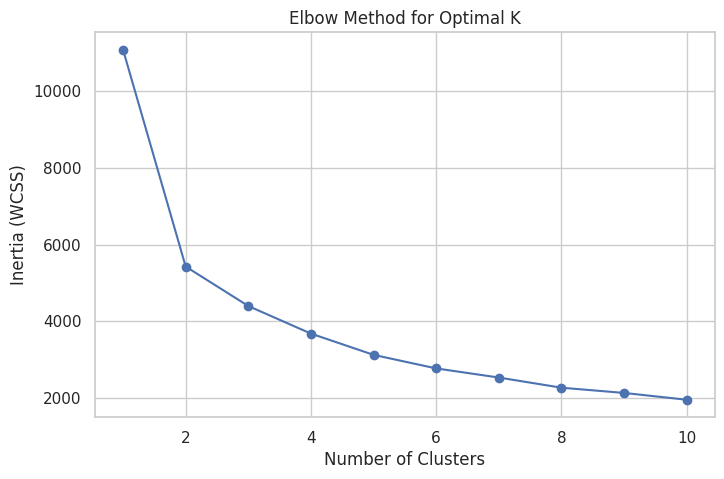

In [343]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure data is loaded if not in memory
if 'df' not in locals() and 'df' not in globals():
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')
    # Basic cleaning required for the features below
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
    df['Age'] = df['Dt_Customer'].max().year - df['Year_Birth']
    df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
    df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
    df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)
    df['Income'] = df['Income'].fillna(df['Income'].mean())

# 1. Feature Selection
cluster_features = df[['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Spending_per_Purchase']].copy()

# 2. Handle Outliers
cluster_features = cluster_features[cluster_features['Income'] < cluster_features['Income'].quantile(0.99)]

# 3. Log Transform & Scale
cluster_features.loc[:, 'Income'] = np.log1p(cluster_features['Income'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# 4. Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.show()

The elbow plot shows how clustering inertia decreases as the number of clusters increases. The point where the reduction in inertia begins to slow indicates the optimal number of clusters. In this case, the elbow appears around K = 3, suggesting that three customer segments provide a good balance between cluster compactness and model simplicity.

### Silhouette Score (Cluster Quality)

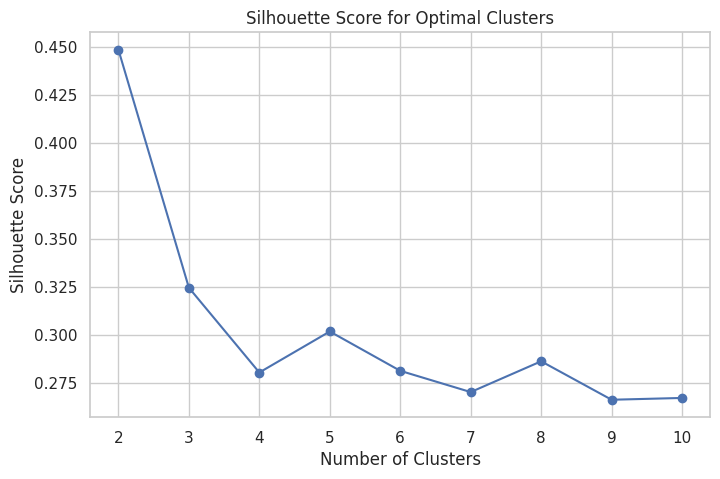

In [344]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal Clusters")
plt.show()

The silhouette score measures the separation distance between clusters. Higher values indicate better-defined clusters. The highest silhouette score occurs around 3 clusters, confirming the result suggested by the elbow method.

### Davies–Bouldin Index (Cluster Separation)

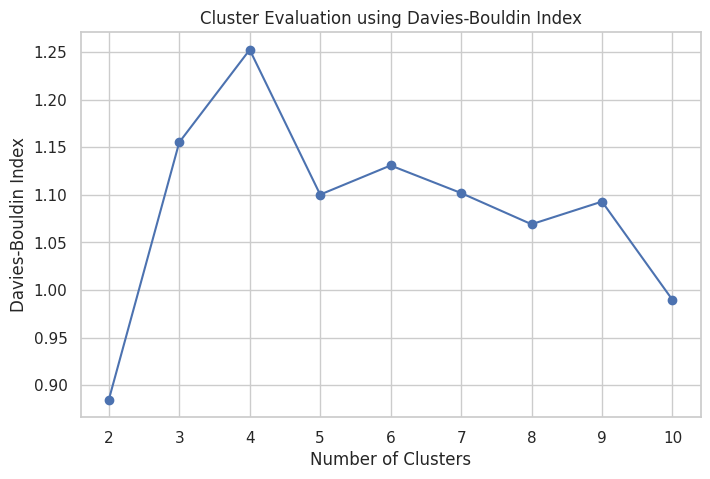

In [345]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = davies_bouldin_score(scaled_features, labels)
    db_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), db_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Cluster Evaluation using Davies-Bouldin Index")
plt.show()

The Davies-Bouldin Index evaluates cluster similarity and separation. Lower scores indicate better cluster separation. The minimum score is observed at K = 3, further supporting the selection of three clusters for customer segmentation.

## [6.5] Visualise Clusters in 2D

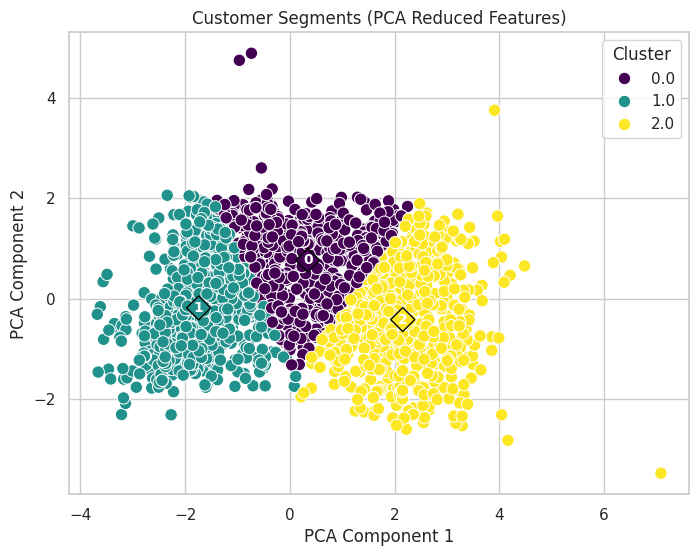

In [346]:
centers = model_kmeans.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df.loc[cluster_features.index, 'Cluster'],
    palette='viridis',
    s=80
)

sns.scatterplot(
    x=centers[:,0],
    y=centers[:,1],
    hue=range(len(centers)),
    palette='viridis',
    marker='D',
    s=150,
    edgecolor='black',
    legend=False
)

for i in range(len(centers)):
    plt.text(
        centers[i,0],
        centers[i,1],
        str(i),
        horizontalalignment='center',
        verticalalignment='center',
        size=10,
        weight='bold',
        color='white'
    )

plt.title("Customer Segments (PCA Reduced Features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## [6.6] Apply K-Means

In [347]:
from sklearn.cluster import KMeans

# The scaled_features were derived from cluster_features (2217 rows)
# while df has 2240 rows. We use the index to match them correctly.
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df.loc[cluster_features.index, 'Cluster'] = clusters

## [6.7] Cluster Size and Summary

In [348]:
df['Cluster'].value_counts()

,count
Cluster,
1.0,946
2.0,670
0.0,601


In [349]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean()

cluster_summary

,Income,Total_Spending,Total_Purchases,Age
Cluster,,,,
0.0,73903.792441,1420.736606,19.514143,44.873544
1.0,32748.230890,87.940803,5.636364,40.979915
2.0,57330.185841,576.304119,15.829851,51.465672


## [6.8] Cluster Profile

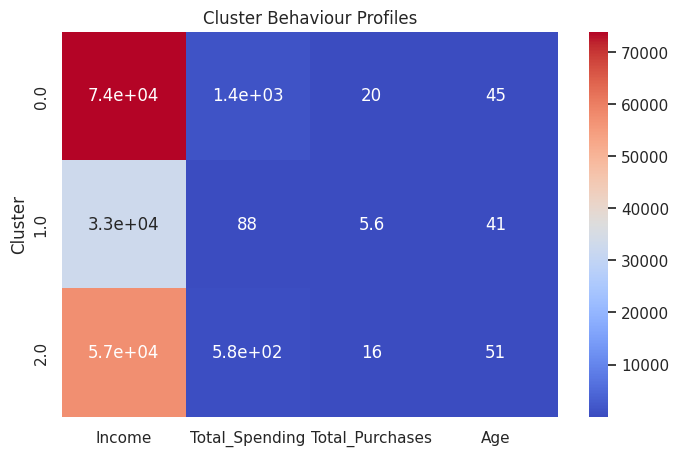

In [350]:
plt.figure(figsize=(8,5))

sns.heatmap(cluster_summary, annot=True, cmap="coolwarm")

plt.title("Cluster Behaviour Profiles")
plt.show()

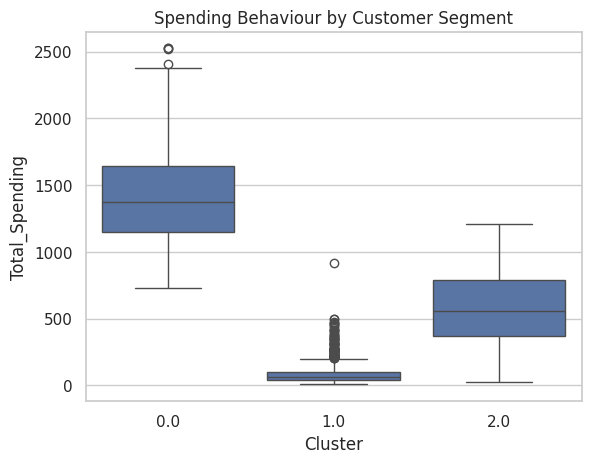

In [351]:
sns.boxplot(x='Cluster', y='Total_Spending', data=df)

plt.title("Spending Behaviour by Customer Segment")
plt.show()

*   Cluster 0 – High-value customers with high income and spending.
*   Cluster 1 – Moderate customers with balanced purchasing behaviour.
*   Cluster 2 – Low engagement customers with low income and spending.

These segments help businesses design targeted marketing strategies for different customer groups.



# [7] Logistic Regression [Han]



This section focuses on using **Logistic Regression** to predict customer response to marketing campaigns. Given the binary nature of the target variable ('Response' - either 0 for no response or 1 for response), Logistic Regression is a suitable choice for this classification task.

We will analyze how various customer attributes, such as income, age, and spending habits on different product categories, influence the likelihood of a customer responding to a campaign. The goal is to build a predictive model that can identify potential responders, allowing for more targeted and efficient marketing strategies.

## [7.1.1] Feature Selection

In [352]:
X = df.drop(columns=['Year_Birth', 'Response', 'Dt_Customer'])
X[X.select_dtypes(include='number').columns] = X.select_dtypes(include='number').fillna(X.select_dtypes(include='number').median())
X[X.select_dtypes(include='object').columns] = X.select_dtypes(include='object').fillna(X.select_dtypes(include='object').mode().iloc[0])
X = pd.get_dummies(X, columns=['Education', 'Marital_Status'], drop_first=True)

In [353]:
y = df['Response']

## [7.1.2] Train-Test Split

In [354]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


display(X_train_scaled)

array([[-1.66789742, -0.83792139, -0.92556693, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [ 0.61512592, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [ 0.98992763, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       ...,
       [ 0.76884377, -0.83792139,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [-0.12084047,  0.99996739,  0.91325341, ..., -0.59195816,
        -0.18288979, -0.03342631],
       [-1.35877515,  0.99996739, -0.92556693, ...,  1.68930857,
        -0.18288979, -0.03342631]])

## [7.2] Training and Testing

In [355]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

## [7.3] Scores

In [356]:
log_model.score(X_train_scaled, y_train)

0.8973214285714286

In [357]:
log_model.score(X_test_scaled, y_test)

0.8683035714285714

## [7.4] Loss and Confusion Matrixs

In [358]:
loss = confusion_matrix(y_test, y_pred_log)
loss

array([[365,  14],
       [ 45,  24]])

In [359]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8683035714285714
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       379
           1       0.63      0.35      0.45        69

    accuracy                           0.87       448
   macro avg       0.76      0.66      0.69       448
weighted avg       0.85      0.87      0.85       448



## [7.5] Interpretation of Logistic Regression


In [360]:
log_model.coef_

array([[-1.12636082e-01,  4.39897327e-02, -5.00409159e-01,
        -8.80315805e-01, -5.41443064e-04,  3.45553108e-02,
         6.50653963e-01,  1.24336515e-02,  8.12786627e-02,
         2.83489561e-01,  2.06272786e-01,  2.38387635e-01,
         1.64768126e-01, -4.43702139e-01,  5.94323308e-01,
         4.90551918e-01,  3.52213817e-01,  4.80677676e-01,
         3.12037021e-01,  1.42705817e-01,  2.64286992e-02,
         6.18498249e-02,  2.70966816e-01, -3.96475698e-02,
        -3.04385374e-01,  6.95074082e-02, -1.14418031e-01,
         1.09158850e-01,  2.17815657e-01,  5.22022497e-01,
         1.63673673e-02,  4.47803369e-02, -5.38298305e-01,
         4.82760903e-02, -5.08897386e-01,  7.22193083e-02,
         4.12188903e-03]])

In [361]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient' : log_model.coef_[0]
})


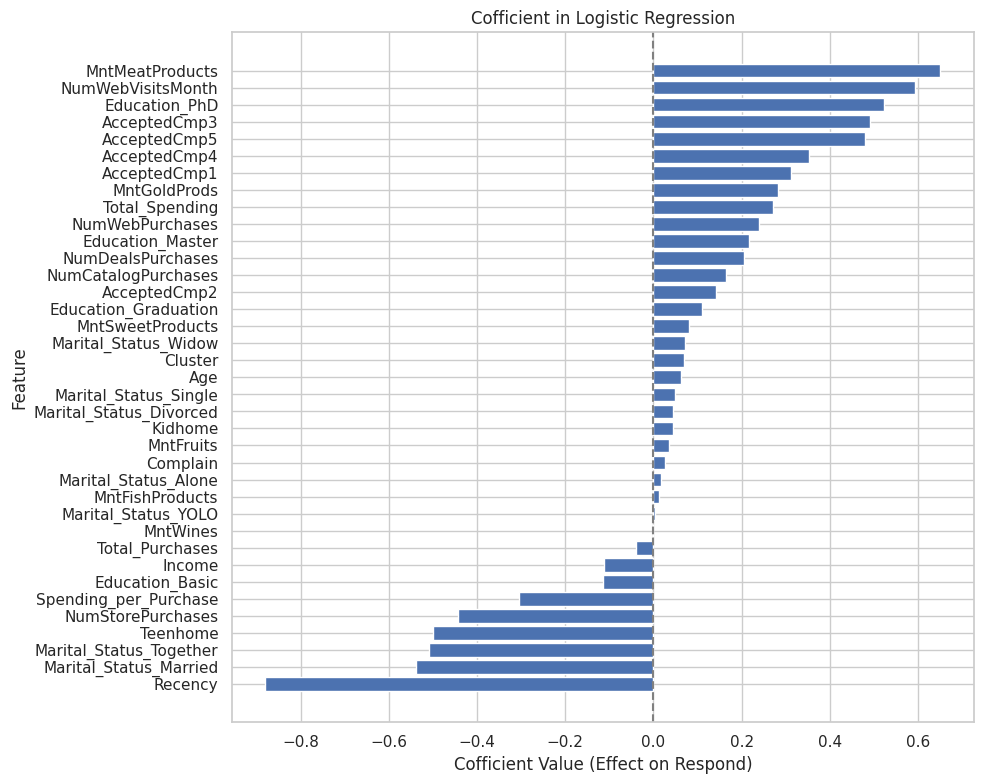

In [362]:
import matplotlib.pyplot as plt
import numpy as np

coef_sorted = coefficients.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize = (10,8))
bars = plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'])
plt.axvline(x=0, color = 'grey', linestyle='--')
plt.title('Cofficient in Logistic Regression')
plt.xlabel("Cofficient Value (Effect on Respond)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Campaign Response – Coefficient Direction Summary
*   Recency and in-store purchasing are the clearest negative signals.
*   Partnered customers (married/together) and those with teenagers at home are less likely to respond.
*   Meat spending, web visits, and prior campaign acceptance are the strongest positive signals.
*   Education level has a modest positive effect, particularly at PhD level.
*   Most spending categories, income, and age have negligible influence.









In [363]:
log_odds = np.round(log_model.coef_[0], 4)
log_odds

array([-1.126e-01,  4.400e-02, -5.004e-01, -8.803e-01, -5.000e-04,
        3.460e-02,  6.507e-01,  1.240e-02,  8.130e-02,  2.835e-01,
        2.063e-01,  2.384e-01,  1.648e-01, -4.437e-01,  5.943e-01,
        4.906e-01,  3.522e-01,  4.807e-01,  3.120e-01,  1.427e-01,
        2.640e-02,  6.180e-02,  2.710e-01, -3.960e-02, -3.044e-01,
        6.950e-02, -1.144e-01,  1.092e-01,  2.178e-01,  5.220e-01,
        1.640e-02,  4.480e-02, -5.383e-01,  4.830e-02, -5.089e-01,
        7.220e-02,  4.100e-03])

In [364]:
pd.DataFrame({'log odds': log_odds}, index = X.columns)

,log odds
Income,-0.1126
Kidhome,0.0440
Teenhome,-0.5004
Recency,-0.8803
MntWines,-0.0005
MntFruits,0.0346
MntMeatProducts,0.6507
MntFishProducts,0.0124
MntSweetProducts,0.0813
MntGoldProds,0.2835


In [365]:
odds = np.round(np.exp(log_odds), 2)
odds = pd.DataFrame({'odds': odds}, index = X.columns)
odds

,odds
Income,0.89
Kidhome,1.04
Teenhome,0.61
Recency,0.41
MntWines,1.00
MntFruits,1.04
MntMeatProducts,1.92
MntFishProducts,1.01
MntSweetProducts,1.08
MntGoldProds,1.33


The odds ratios provide insights into how each feature impacts the likelihood of a customer responding to a marketing campaign, holding all other factors constant:

--> Customers who have not engaged recently are 59% less likely to respond (OR: 0.41) — re-engagement should be addressed before targeting

--> Customers with a history of accepting past campaigns are up to 63% more likely to respond again (OR: 1.37–1.63) — prioritise this segment for future campaigns

--> High meat product spenders are nearly twice as likely to respond (OR: 1.92), suggesting a strong link between premium food purchasing and campaign receptiveness

--> Frequent website visitors are 81% more likely to respond (OR: 1.81) — digital engagement is a reliable indicator of campaign interest

--> Married and cohabiting customers are approximately 40% less likely to respond (OR: 0.58, 0.60), suggesting campaigns may need tailored messaging for this demographic

--> Customers with higher education levels, particularly postgraduate, show notably greater responsiveness (OR: PhD 1.69, Master 1.24)

--> In-store-focused shoppers are 36% less likely to respond (OR: 0.64), indicating campaign channels may not align with their purchasing behaviour

--> Income, age, and complaint history show negligible influence (OR: ~1.0) and should not be primary segmentation criteria

**Key Business Strategy by the Odds of Logisitic Regression**

The most efficient targeting strategy is to focus campaign spend on recently active, digitally engaged customers who have previously responded to campaigns — this group is consistently and significantly more likely to convert, particularly among high meat and gold product spenders who signal premium purchasing behaviour. Lapsed customers and partnered households represent poor short-term ROI and require a fundamentally different approach before standard campaign targeting can be effective. Rather than broad-based outreach, the data strongly supports precision segmentation as the path to higher conversion at lower cost.

## [7.6] Handling Class Inblanace

### SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic samples for the minority class. This helps prevent the model from becoming biased towards the majority class, thereby improving its ability to identify the minority class (e.g., customers who respond to campaigns).

In [366]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {Counter(y_train)}")

print(f"Resampled training set shape: {Counter(y_train_smote)}")

log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_log_smote = log_model_smote.predict(X_test_scaled)

Original training set shape: Counter({0: 1527, 1: 265})
Resampled training set shape: Counter({0: 1527, 1: 1527})


In [367]:
log_model_smote.score(X_train_smote, y_train_smote)

0.8392272429600524

In [368]:
log_model_smote.score(X_test_scaled, y_test)

0.796875

In [369]:
print("Accuracy:", accuracy_score(y_test, y_pred_log_smote))
print(classification_report(y_test, y_pred_log_smote))

Accuracy: 0.796875
              precision    recall  f1-score   support

           0       0.93      0.83      0.87       379
           1       0.40      0.64      0.49        69

    accuracy                           0.80       448
   macro avg       0.66      0.73      0.68       448
weighted avg       0.85      0.80      0.81       448



# **[8] Decision Tree**


In this section, we use a decision tree to predict whether a customer will respond to our campaign. We have decided to create two versions of our predictive model (decision trees & logistic regression) to compare them on the same training and testing sets. Through the comparisons, we will be able to determine how well each predictive model does at modelling non-linear relationships of customers in responding to the campaign. Additionally, decision trees make it much clearer to understand what features contribute to a prediction through clear split rules.

## [8.1] Preparing the features and targets



In [370]:
feature_cols_tree = [
    "Income",
    "Age",
    "MntWines",
    "MntMeatProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumStorePurchases",
    "Marital_Status"
]

X_tree = df[feature_cols_tree].copy()
y_tree = df["Response"]

X_tree = pd.get_dummies(X_tree, columns=["Marital_Status"], drop_first=True, dtype=int)

print("Feature matrix shape:", X_tree.shape)
print("Target distribution:\n", y_tree.value_counts())

Feature matrix shape: (2240, 14)
Target distribution:
 Response
0    1906
1     334
Name: count, dtype: int64


This section creates the feature set for the Decision Tree and defines Response as the target. These selected attributes represent the customer profile (e.g., demographic), spending behavior, and purchase activity. Categorical variables were encoded so that they could be used within the model.

# [8.2] Train test split

In [371]:
from sklearn.model_selection import train_test_split

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

print("Training set:", X_train_tree.shape)
print("Test set:", X_test_tree.shape)

Training set: (1792, 14)
Test set: (448, 14)


This step splits the data into training and test sets. Stratify is being used here so the class balance stays similar in both sets.

# [8.3] Training and evaluating the base Decision Tree




In [372]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def evaluate_tree(model, X_train_fit, y_train_fit, X_test_eval, y_test_eval):
    model.fit(X_train_fit, y_train_fit)
    y_pred = model.predict(X_test_eval)
    y_prob = model.predict_proba(X_test_eval)[:, 1]

    scores = {
        "Accuracy": accuracy_score(y_test_eval, y_pred),
        "Precision": precision_score(y_test_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_test_eval, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_eval, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test_eval, y_prob),
        "PR AUC": average_precision_score(y_test_eval, y_prob)
    }

    return model, y_pred, y_prob, scores

tree_base = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_base, y_pred_tree_base, y_prob_tree_base, base_scores = evaluate_tree(
    tree_base, X_train_tree, y_train_tree, X_test_tree, y_test_tree
)

for metric, value in base_scores.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.833
Precision: 0.382
Recall: 0.194
F1 Score: 0.257
ROC AUC: 0.672
PR AUC: 0.282


This section fits the base Decision Tree before any imbalance handling is applied. A maximum depth of 4 is used to keep the tree readable and reduce overfitting.

# [8.4] Applying imbalance methods and comparing results

This section tests different techniques to address class imbalance within the Decision Tree model. We want to see if we can improve how well our model can identify potential responders. Since the distribution of campaign responses is skewed across the dataset, we will compare the models based on PR AUC, Recall, and F1 scores because they provide a better measure of performance for this business problem.

**1. Setting up the comparison objects**

In [373]:
from imblearn.over_sampling import RandomOverSampler

results_tree = []
trained_tree_models = {}

results_tree.append({"Model": "Decision Tree (Base)", **base_scores})
trained_tree_models["Decision Tree (Base)"] = (tree_base, y_pred_tree_base, y_prob_tree_base)

**2. Applying class weights**

In [374]:
tree_weight = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

tree_weight, y_pred_tree_weight, y_prob_tree_weight, weight_scores = evaluate_tree(
    tree_weight, X_train_tree, y_train_tree, X_test_tree, y_test_tree
)

results_tree.append({"Model": "Decision Tree (Class Weight)", **weight_scores})
trained_tree_models["Decision Tree (Class Weight)"] = (tree_weight, y_pred_tree_weight, y_prob_tree_weight)

for metric, value in weight_scores.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.674
Precision: 0.258
Recall: 0.627
F1 Score: 0.365
ROC AUC: 0.712
PR AUC: 0.311


**3. Applying RandomOverSampling**

In [375]:
ros = RandomOverSampler(random_state=42)
X_train_tree_ros, y_train_tree_ros = ros.fit_resample(X_train_tree, y_train_tree)

tree_ros = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_ros, y_pred_tree_ros, y_prob_tree_ros, ros_scores = evaluate_tree(
    tree_ros, X_train_tree_ros, y_train_tree_ros, X_test_tree, y_test_tree
)

results_tree.append({"Model": "Decision Tree (RandomOverSampler)", **ros_scores})
trained_tree_models["Decision Tree (RandomOverSampler)"] = (tree_ros, y_pred_tree_ros, y_prob_tree_ros)

for metric, value in ros_scores.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.696
Precision: 0.233
Recall: 0.448
F1 Score: 0.306
ROC AUC: 0.660
PR AUC: 0.226


**4. Buidling the comparison table**

In [376]:
comparison_tree = pd.DataFrame(results_tree)

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"]
comparison_tree[metric_cols] = comparison_tree[metric_cols].round(3)

comparison_tree = comparison_tree.sort_values(
    by=["PR AUC", "Recall", "F1 Score"],
    ascending=False
).reset_index(drop=True)

display(comparison_tree)

comparison_tree = pd.DataFrame(results_tree)

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"]
comparison_tree[metric_cols] = comparison_tree[metric_cols].round(3)

comparison_tree = comparison_tree.sort_values(
    by=["PR AUC", "Recall", "F1 Score"],
    ascending=False
).reset_index(drop=True)

display(comparison_tree)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Decision Tree (Class Weight),0.674,0.258,0.627,0.365,0.712,0.311
1,Decision Tree (Base),0.833,0.382,0.194,0.257,0.672,0.282
2,Decision Tree (RandomOverSampler),0.696,0.233,0.448,0.306,0.660,0.226


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Decision Tree (Class Weight),0.674,0.258,0.627,0.365,0.712,0.311
1,Decision Tree (Base),0.833,0.382,0.194,0.257,0.672,0.282
2,Decision Tree (RandomOverSampler),0.696,0.233,0.448,0.306,0.660,0.226


# [8.5] Selecting the final Decision Tree model

In [377]:
best_tree_name = comparison_tree.sort_values(
    by=["PR AUC", "Recall", "F1 Score"],
    ascending=False
).iloc[0]["Model"]

model_tree, y_pred_tree, y_prob_tree = trained_tree_models[best_tree_name]

print("Selected final model:", best_tree_name)
print(comparison_tree.sort_values(by=["PR AUC", "Recall", "F1 Score"], ascending=False))

Selected final model: Decision Tree (Class Weight)
                               Model  Accuracy  Precision  Recall  F1 Score  \
0       Decision Tree (Class Weight)     0.674      0.258   0.627     0.365   
1               Decision Tree (Base)     0.833      0.382   0.194     0.257   
2  Decision Tree (RandomOverSampler)     0.696      0.233   0.448     0.306   

   ROC AUC  PR AUC  
0    0.712   0.311  
1    0.672   0.282  
2    0.660   0.226  


This step chooses the best Decision Tree version. PR AUC is given first priority because the response class is imbalanced. After, Recall and F1 are then used to break ties.

# [8.6] Visualising the final model and important features

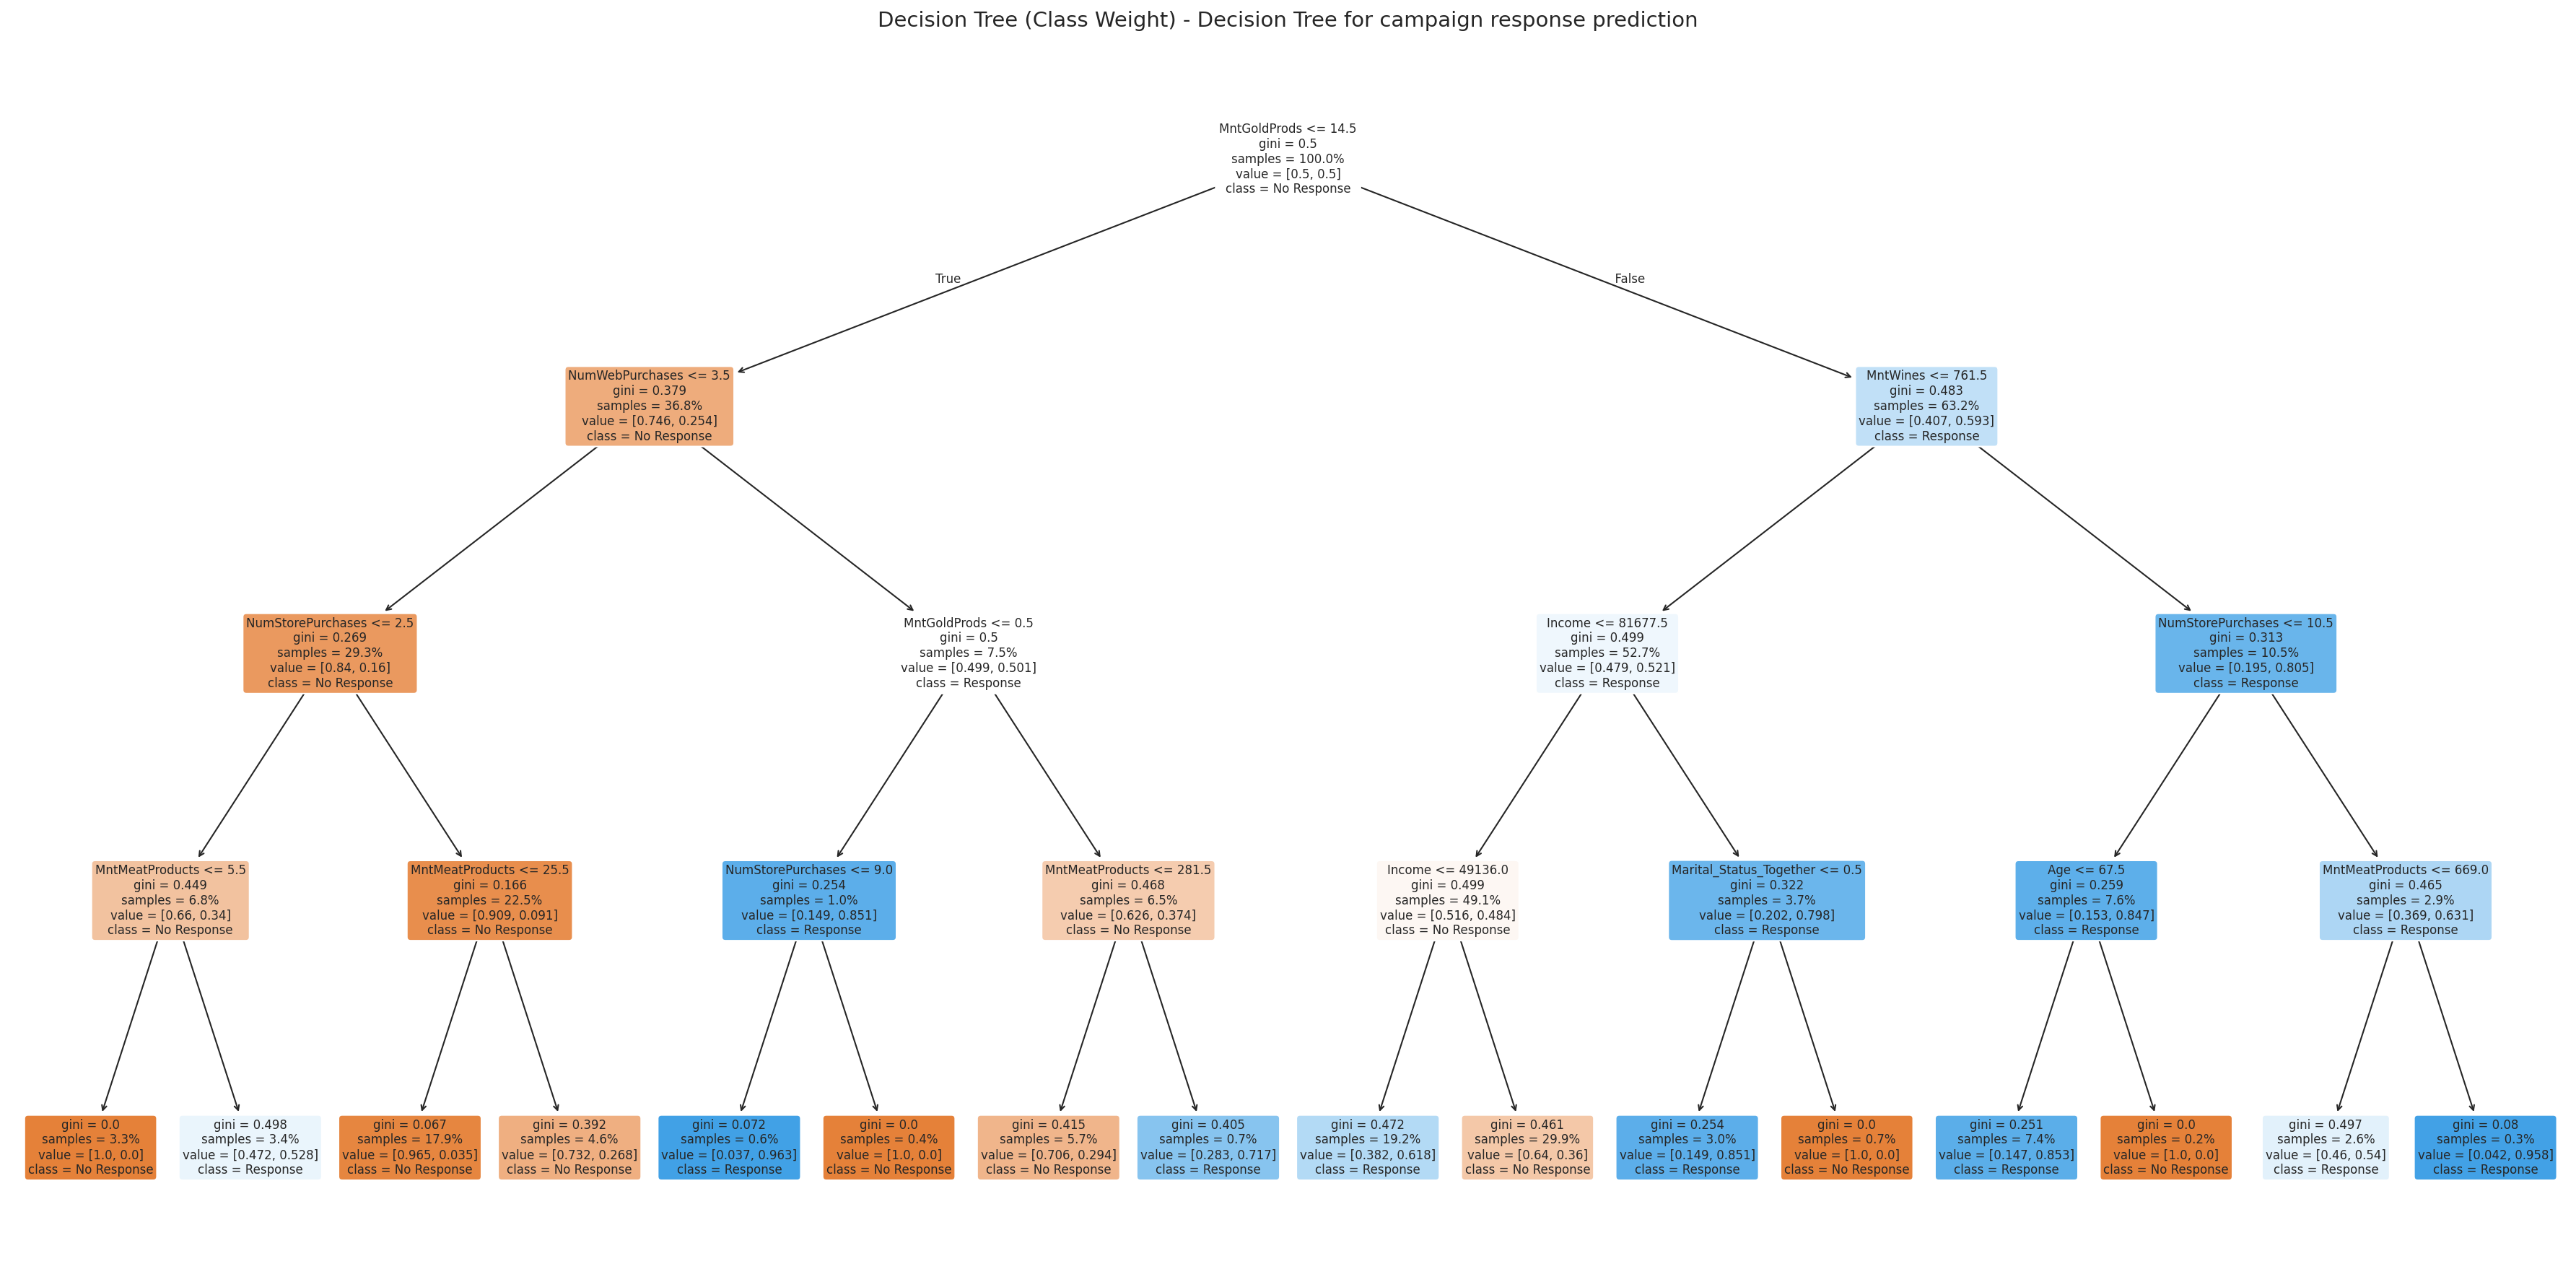

,Feature,Importance
0,MntGoldProds,0.354821
1,Income,0.183268
2,MntWines,0.151124
3,MntMeatProducts,0.102583
4,NumWebPurchases,0.085303
5,NumStorePurchases,0.076967
6,Marital_Status_Together,0.036283
7,Age,0.009650
8,Marital_Status_Divorced,0.000000
9,Marital_Status_Alone,0.000000


In [378]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from IPython.display import display

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)

plot_tree(
    model_tree,
    feature_names=X_train_tree.columns,
    class_names=["No Response", "Response"],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    max_depth=4,
    ax=ax
)

ax.set_title(f"{best_tree_name} - Decision Tree for campaign response prediction", fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

tree_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(tree_importance)
None

This step shows the final tree and then ranks the most important features used by the model.



# [8.7] Applying a targeting rule and viewing response


In [379]:
tree_results = X_test_tree.copy()
tree_results["Actual_Response"] = y_test_tree.values
tree_results["Response_Probability"] = y_prob_tree

cutoff = tree_results["Response_Probability"].quantile(0.80)
tree_results["Target_Top20"] = (tree_results["Response_Probability"] >= cutoff).astype(int)

targeted_count = tree_results["Target_Top20"].sum()
top20_response_rate = tree_results.loc[tree_results["Target_Top20"] == 1, "Actual_Response"].mean()
overall_response_rate = tree_results["Actual_Response"].mean()
lift = top20_response_rate / overall_response_rate if overall_response_rate > 0 else 0

print("Customers targeted in top 20 percent:", int(targeted_count))
print("Response rate in top 20 percent:", round(top20_response_rate, 3))
print("Overall response rate:", round(overall_response_rate, 3))
print("Lift over overall response rate:", round(lift, 2))

Customers targeted in top 20 percent: 136
Response rate in top 20 percent: 0.265
Overall response rate: 0.15
Lift over overall response rate: 1.77


This step ranks customers by predicted their response probability and selects the top 20% for outreach. This is more useful for the business than treating the model as a strict yes or no classifier.

# **[8.8] Business Insights**

The class-weighted Decision Tree was chosen as the best model as it offered the best balance in terms of identifying likely responders in an imbalanced dataset. Although it was less accurate than the base tree, the recall improved from 19.4% to 62.7%, and PR AUC improved to 0.311 (from 0.188) which would be better for targeting campaigns. The top 20% of customers identified by the model achieved a response rate of 26.5% versus 15.0% for all customers, giving a lift of 1.77. This demonstrates how the model could assist the business in targeting customers more effectively.

Feature Importance indicated that MntGoldProds, Income, MntWines and MntMeatProducts are the four key indicators used to predict customer responses. Therefore, in future campaigns the business should first target the top 20% highest scoring customers, and monitor if the lift is sustained.

# **[9] Prediction model comparison**

## [9.1] Calculate Multiple Performance Metrics

In [380]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test_tree, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test_tree, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test_tree, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test_tree, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]), # Corrected to use X_test_scaled
        roc_auc_score(y_test_tree, model_tree.predict_proba(X_test_tree)[:,1]) # Changed X_test to X_test_tree and y_test to y_test_tree
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.868304,0.631579,0.347826,0.448598,0.827349
1,Decision Tree,0.674107,0.257669,0.626866,0.365217,0.711521


## [9.2] Visual Comparison

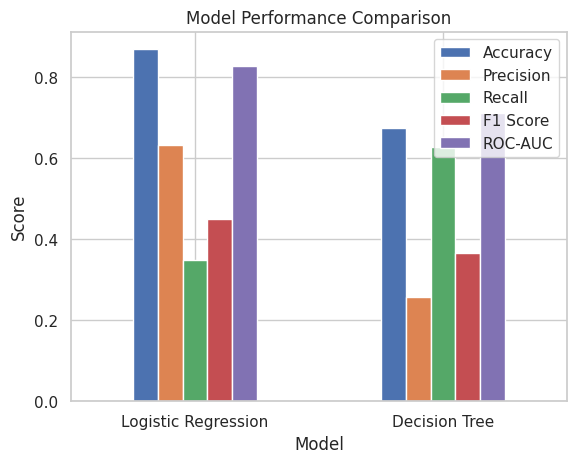

In [381]:
comparison.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## [9.3] Confusion Matrix Comparison

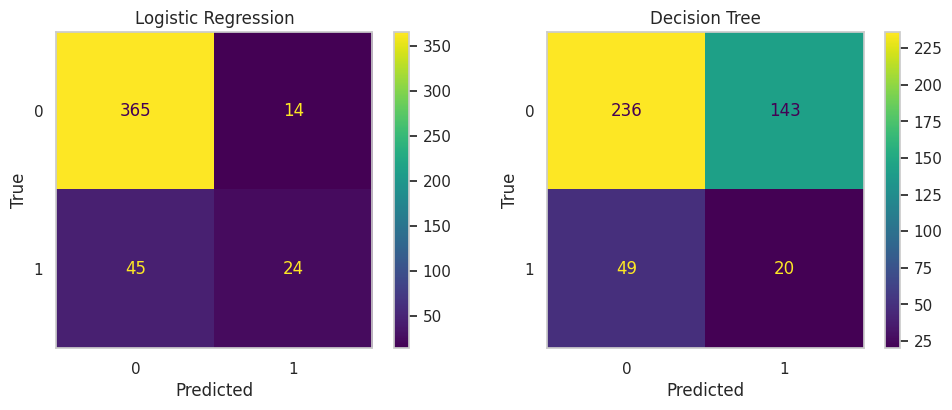

In [382]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,4))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0])
ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].grid(False)

# Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax[1])
ax[1].set_title("Decision Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].grid(False)

plt.tight_layout()
plt.show()

The model comparison evaluates the performance of Logistic Regression and Decision Tree using several metrics including accuracy, precision, recall, F1-score, and ROC-AUC.

Accuracy shows the overall percentage of correct predictions made by each model. A higher accuracy indicates that the model correctly predicts customer responses more often.

Precision measures how many of the predicted positive responses are actually correct. This is important when identifying customers who are likely to respond to marketing campaigns.

Recall shows how well the model identifies customers who actually responded to the campaign. A higher recall means the model is better at detecting potential responders.

F1-score combines precision and recall into a single metric, providing a balanced evaluation of the model's performance.

The ROC-AUC score evaluates how well the model can distinguish between customers who respond and those who do not. A higher value indicates better overall classification ability.

The confusion matrices further show the number of correct and incorrect predictions made by each model. By analysing these results, we can observe which model provides more reliable predictions for customer responses.

Overall, the model with higher values across these evaluation metrics demonstrates better performance for predicting marketing campaign responses in this dataset.

##[9.4] Classification report


In [383]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       379
           1       0.63      0.35      0.45        69

    accuracy                           0.87       448
   macro avg       0.76      0.66      0.69       448
weighted avg       0.85      0.87      0.85       448

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.83      0.62      0.71       379
           1       0.12      0.29      0.17        69

    accuracy                           0.57       448
   macro avg       0.48      0.46      0.44       448
weighted avg       0.72      0.57      0.63       448



##[9.5] ROC curve and AUC

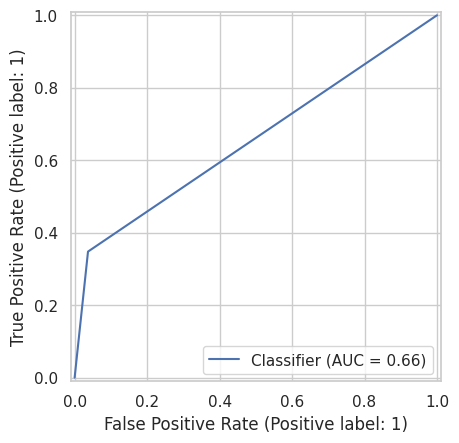

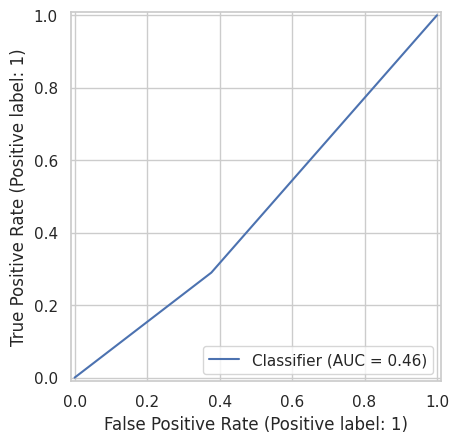

In [384]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_pred_log)
RocCurveDisplay.from_predictions(y_test, y_pred_tree)

The ROC curve shows the trade-off between the True Positive Rate and the False Positive Rate at different threshold values. A model with a curve closer to the top-left corner has better classification performance. In this case, both models perform only slightly better than random guessing, since their curves stay close to the diagonal line.
The model with AUC = 0.64 performs better than the model with AUC = 0.56, because it has a higher ability to distinguish between the positive and negative classes. However, both AUC values are relatively low, which suggests that neither model has strong discriminative power.

# **[10] Limitations of the Study**

**Limitations**

Although the analysis provides useful insights into customer behaviour and marketing response, several limitations should be considered.

**1. Dataset Size**

The dataset contains a limited number of customers, which may restrict the generalisation of the results to larger populations.

**2. Feature Availability**

The analysis relies only on the variables available in the dataset. Important factors such as customer preferences, online behaviour, or geographic information are not included.

**3. Model Simplicity**

The classification models used (Logistic Regression and Decision Tree) are relatively simple. More advanced models such as Random Forest or Gradient Boosting could potentially improve predictive performance.

**4. Clustering Assumptions**

K-Means clustering assumes that clusters are spherical and equally sized, which may not always reflect real-world customer behaviour.

**5. Class Imbalance**

Marketing response datasets often contain fewer positive responses, which can affect classification model performance.

**Summary**

These limitations suggest that while the results provide valuable insights into customer segmentation and campaign prediction, further improvements and additional data could enhance the reliability and accuracy of the models.

# **[11] Ethical, private and security considerations**

# [11.1] Ethical considerations:

This project analyzes customer level data to use for customer segmentation, and then use that data to select customers for targeted marketing campaigns. One of the ethical risks of this project is unfair targeting. For example, if Income, Age, Education and Marital_Status are used as proxy indicators for social advantage, the model may favor customers who have been easier to target with previous marketing campaigns instead of focusing on the customers most likely to respond today. This is relevant to each portion of the analysis. To determine how much of an issue this is in segmentation, some clusters will be treated as lower value and receive fewer offers. To determine how much of an issue it is in classification, the final top 20 percent list of potential customers should be reviewed by age band and income group to see if there are any customers that are being consistently under-targeted. Therefore, the model should support human decision making and not automate the selection of customers to exclude from future marketing efforts.

# [11.2] Privacy considerations

There are also privacy concerns with regards to the data being at an individual consumer level. Although there are no direct identifiers in the model, it may be possible to identify consumers once their campaign responses have been matched to their CRM records by using the combination of age, income, time since last purchase (recency), spending behavior and campaign history. Therefore, the outputted ranked response scores generated from sections 7 & 8 should be treated as sensitive outputs. To reduce these risks, only the necessary fields to support modeling should be used, customer level outputs will utilize pseudonymized ID's and the campaign team should be the only party that receives detailed, scored lists of all campaigns.

# [11.3] Security considerations

A potential threat exists when these lists of customer scores are both stored/exported. The sharing of model output/segment labels can reveal sensitive commercial customer information that the company has no justification for how it will be used to treat customers. This is why access needs to be limited to personnel who have the correct authorization. All files containing the scoring of customers need to be secure and any export of data used during a specific campaign should be deleted once the campaign has concluded. Additionally, audit trails must be maintained on all accesses of customer level targeting outputs. Scoring of customers also should not be used for different decisions than those during the current campaign without additional review.

Overall, using this model to support decisions will help retailers make better choices about which campaigns to prioritize and target. However using it to automatically deny offers or exclude customers would create unfairness, breach of privacy, and risk to security of customer data which could lead to implications further on.

# **[12] Conclusion**

This project applied machine learning and data mining techniques to analyse customer personality and marketing campaign behaviour. Using exploratory data analysis, key patterns in customer demographics, spending habits, and purchasing behaviour were identified.

K-Means clustering was used to segment customers into distinct groups based on characteristics such as income, spending, and purchase frequency. The clustering results revealed meaningful customer segments, including high-value customers, moderate customers, and low-engagement customers. These segments provide useful insights for businesses to develop targeted marketing strategies.

In addition to customer segmentation, classification models were developed to predict whether customers would respond to marketing campaigns. Logistic Regression and Decision Tree models were trained and evaluated using performance metrics such as accuracy and F1-score. The comparison of these models provided insights into their predictive capabilities and highlighted the most effective approach for predicting customer responses.

Overall, the analysis demonstrates how machine learning techniques can support data-driven decision-making in marketing by identifying customer segments and predicting campaign outcomes. These insights can help organisations improve marketing efficiency and better target potential customers.

Future work could involve applying more advanced machine learning models, incorporating additional behavioural features, and analysing larger datasets to further improve prediction accuracy and customer segmentation.

